In [1]:
!python --version

Python 3.13.13


In [56]:
import os
import cv2
import easyocr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from difflib import SequenceMatcher
plt.rcParams['font.family'] = 'Tahoma'

In [ ]:
reader = easyocr.Reader(['th'], gpu=True)
result = reader.readtext('license_plate.jpg')
print(result)

[([[np.int32(143), np.int32(63)], [np.int32(526), np.int32(63)], [np.int32(526), np.int32(322)], [np.int32(143), np.int32(322)]], 'กท', np.float64(0.9986401921484834)), ([[np.int32(620), np.int32(61)], [np.int32(1230), np.int32(61)], [np.int32(1230), np.int32(320)], [np.int32(620), np.int32(320)]], '2058', np.float64(0.9996482133865356)), ([[np.int32(347), np.int32(354)], [np.int32(946), np.int32(354)], [np.int32(946), np.int32(498)], [np.int32(347), np.int32(498)]], 'ฉะเชิงเทรา', np.float64(0.9911551381724858)), ([[np.int32(52), np.int32(495)], [np.int32(211), np.int32(495)], [np.int32(211), np.int32(531)], [np.int32(52), np.int32(531)]], '572982949', np.float64(0.9999534283619819))]


In [7]:
def plot_ocr(image_path):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = reader.readtext(image_path)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)

    # Draw bbox
    for (bbox, text, prob) in results:
        # bbox: 4 points
        xs = [point[0] for point in bbox] + [bbox[0][0]]
        ys = [point[1] for point in bbox] + [bbox[0][1]]

        plt.plot(xs, ys, color='lime', linewidth=2)

        # Put text (top-left corner)
        x, y = bbox[0]
        plt.text(x, y - 10, f"{text} ({prob:.2f})",
                color='red', fontsize=12, backgroundcolor='white')

    plt.axis('off')
    plt.title('OCR Bounding Boxes')
    plt.show()

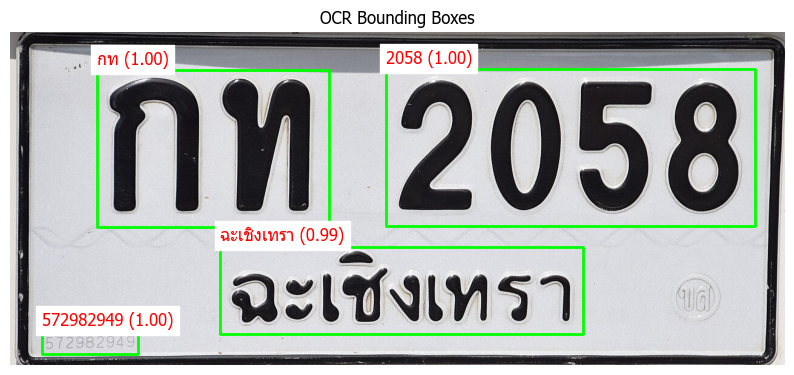

In [8]:
plot_ocr('license_plate.jpg')

In [29]:
thai_map = {
    "A01": "ก",
    "A02": "ข",
    "A03": "ฃ",
    "A04": "ค",
    "A05": "ฅ",
    "A06": "ฆ",
    "A07": "ง",
    "A08": "จ",
    "A09": "ฉ",
    "A10": "ช",
    "A11": "ซ",
    "A12": "ฌ",
    "A13": "ญ",
    "A14": "ฎ",
    "A15": "ฏ",
    "A16": "ฐ",
    "A17": "ฑ",
    "A18": "ฒ",
    "A19": "ณ",
    "A20": "ด",
    "A21": "ต",
    "A22": "ถ",
    "A23": "ท",
    "A24": "ธ",
    "A25": "น",
    "A26": "บ",
    "A27": "ป",
    "A28": "ผ",
    "A29": "ฝ",
    "A30": "พ",
    "A31": "ฟ",
    "A32": "ภ",
    "A33": "ม",
    "A34": "ย",
    "A35": "ร",
    "A36": "ล",
    "A37": "ว",
    "A38": "ศ",
    "A39": "ษ",
    "A40": "ส",
    "A41": "ห",
    "A42": "ฬ",
    "A43": "อ",
    "A44": "ฮ",
}

In [47]:
def load_province_map(csv_path="province_map.csv"):
    df = pd.read_csv(csv_path)
    mapping = dict(zip(df['abbr_en'], df['province_th']))
    return mapping

def map_province(label, mapping):
    return mapping.get(label, None)

def decode_thai_char(label):
    if label in thai_map:
        return thai_map[label]
    return label

def plot_test_image(csv_path, image_dir, idx=0):
    df = pd.read_csv(csv_path)
    first_file = df.iloc[idx]['filename']
    df_img = df[df['filename'] == first_file]

    img_path = os.path.join(image_dir, first_file)
    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    province_map = load_province_map()
    boxes = []

    # ── decode labels ────────────────────────────────────────────
    for _, row in df_img.iterrows():
        xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
        label = str(row['class'])

        if label.isnumeric():
            pass                                   # keep digits as-is
        elif label.startswith("A"):
            label = decode_thai_char(label)        # Thai character
        else:
            label = map_province(label, province_map)   # province abbreviation

        boxes.append({
            "bbox": [xmin, ymin, xmax, ymax],
            "label": label,
            "y_center": (ymin + ymax) / 2,
        })

    # ── split top / bottom using k-means on y_center ─────────────
    # More robust than a single median split for unbalanced lines
    y_vals = np.array([b["y_center"] for b in boxes], dtype=np.float32).reshape(-1, 1)
    _, labels_km, centers = cv2.kmeans(
        y_vals, 2, None,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2),
        10, cv2.KMEANS_RANDOM_CENTERS
    )
    # label 0 → whichever cluster has smaller mean y → top line
    top_cluster = int(np.argmin(centers))
    labels_km = labels_km.flatten()

    top_line    = sorted([b for b, l in zip(boxes, labels_km) if l == top_cluster],
                         key=lambda x: x["bbox"][0])
    bottom_line = sorted([b for b, l in zip(boxes, labels_km) if l != top_cluster],
                         key=lambda x: x["bbox"][0])

    # ── merge text & bbox ─────────────────────────────────────────
    def merge_bbox(line):
        xs = [b["bbox"][0] for b in line] + [b["bbox"][2] for b in line]
        ys = [b["bbox"][1] for b in line] + [b["bbox"][3] for b in line]
        return [min(xs), min(ys), max(xs), max(ys)]

    top_text    = "".join(b["label"] for b in top_line)
    bottom_text = "".join(b["label"] for b in bottom_line)
    top_bbox    = merge_bbox(top_line)
    bottom_bbox = merge_bbox(bottom_line)

    # ── plot ──────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(image)

    for bbox, text, color in [
        (top_bbox,    top_text,    "black"),
        (bottom_bbox, bottom_text, "black"),
    ]:
        xmin, ymin, xmax, ymax = bbox
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)

        ax.text(
            xmin, ymin - 10, text,
            fontsize=14,
            color=color,
            bbox=dict(facecolor="white", alpha=0.7, pad=2, edgecolor="none"),
        )

    ax.axis("off")
    plt.tight_layout()
    plt.show()

    return {
        "top":    {"text": top_text,    "bbox": top_bbox},
        "bottom": {"text": bottom_text, "bbox": bottom_bbox},
    }

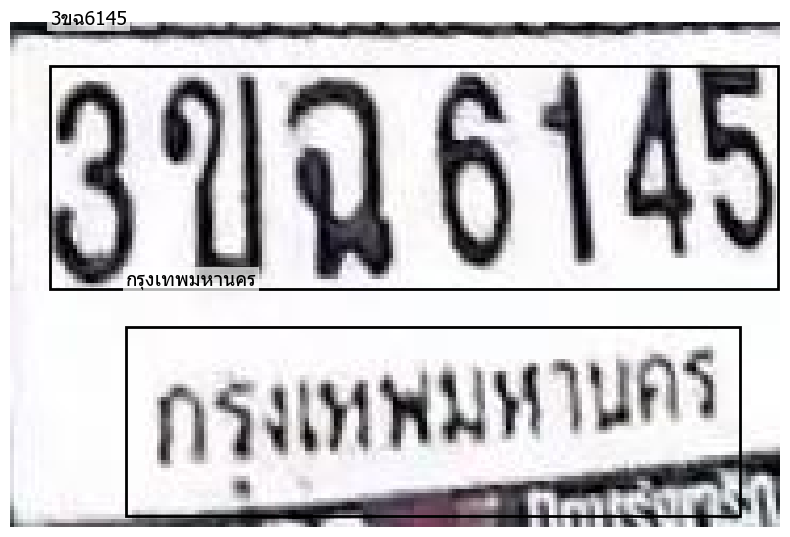

{'top': {'text': '3ขฉ6145', 'bbox': [9, 10, 182, 63]},
 'bottom': {'text': 'กรุงเทพมหานคร', 'bbox': [27, 72, 173, 117]}}

In [50]:
plot_test_image(
    csv_path=r'LPR-plate-1\test\_annotations.csv',
    image_dir=r'LPR-plate-1\test',
    idx=155
)

In [85]:
import re

def normalize_text(text):
    """
    Keep only Thai characters and digits, strip everything else.
    Thai unicode range: U+0E00–U+0E7F
    """
    return re.sub(r'[^\u0e00-\u0e7f0-9]', '', text)

In [86]:
from cer import calculate_cer

def decode_label(label, province_map):
    if label.isnumeric():
        return label
    if label.startswith("A"):
        return decode_thai_char(label)
    return province_map.get(label, label)

def build_ground_truth(csv_path, image_dir, province_map_path="province_map.csv",
                        plate_margin_frac=0.05, idx=0):
    """
    Returns a dict per image:
      {
        "filename": str,
        "image_w": int, "image_h": int,
        "top":    {"text": str, "bbox": [xmin,ymin,xmax,ymax]},
        "bottom": {"text": str, "bbox": [xmin,ymin,xmax,ymax]},
      }

    Noise filtering:
      Boxes whose x-center is outside the plate's main cluster (left 10% strip)
      or whose width < plate_margin_frac * image_w are discarded.
      This removes corner stamps like "572982949".
    """
    df = pd.read_csv(csv_path)
    province_map = load_province_map(province_map_path)

    first_file = df.iloc[idx]['filename']
    df_img = df[df['filename'] == first_file].copy()

    img_path = os.path.join(image_dir, first_file)
    img = cv2.imread(img_path)
    img_h, img_w = img.shape[:2]

    boxes = []
    for _, row in df_img.iterrows():
        xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
        label = decode_label(str(row['class']), province_map)

        # ── Noise filter: skip tiny or far-left corner boxes ──────────────
        box_w = xmax - xmin
        box_h = ymax - ymin
        x_center = (xmin + xmax) / 2

        if box_w < plate_margin_frac * img_w:          # too narrow → stamp/noise
            continue
        if box_h < plate_margin_frac * img_h:          # too short  → stamp/noise
            continue
        if x_center < 0.08 * img_w:                    # far-left corner → noise
            continue

        boxes.append({
            "bbox": [xmin, ymin, xmax, ymax],
            "label": label,
            "y_center": (ymin + ymax) / 2,
        })

    # ── Split top / bottom via k-means on y_center ────────────────────────
    y_vals = np.array([b["y_center"] for b in boxes], dtype=np.float32).reshape(-1, 1)
    _, km_labels, centers = cv2.kmeans(
        y_vals, 2, None,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2),
        10, cv2.KMEANS_RANDOM_CENTERS,
    )
    top_cluster = int(np.argmin(centers))
    km_labels = km_labels.flatten()

    top_line    = sorted([b for b, l in zip(boxes, km_labels) if l == top_cluster],
                         key=lambda x: x["bbox"][0])
    bottom_line = sorted([b for b, l in zip(boxes, km_labels) if l != top_cluster],
                         key=lambda x: x["bbox"][0])

    def merge(line):
        text = "".join(b["label"] for b in line)
        xs = [b["bbox"][0] for b in line] + [b["bbox"][2] for b in line]
        ys = [b["bbox"][1] for b in line] + [b["bbox"][3] for b in line]
        return {"text": text, "bbox": [min(xs), min(ys), max(xs), max(ys)]}

    return {
        "filename": first_file,
        "image_w": img_w,
        "image_h": img_h,
        "top":    merge(top_line),
        "bottom": merge(bottom_line),
    }

def run_easyocr(image_path, gt, conf_threshold=0.1,
                lang_list=None, gpu=False, _reader=None):
    if _reader is None:
        lang_list = lang_list or ['th', 'en']
        _reader = easyocr.Reader(lang_list, gpu=gpu)

    raw = _reader.readtext(image_path, detail=1)

    def easyocr_to_xyxy(box_pts):
        pts = np.array(box_pts)
        return [int(pts[:,0].min()), int(pts[:,1].min()),
                int(pts[:,0].max()), int(pts[:,1].max())]

    def iou(a, b):
        ax1,ay1,ax2,ay2 = a
        bx1,by1,bx2,by2 = b
        ix1, iy1 = max(ax1,bx1), max(ay1,by1)
        ix2, iy2 = min(ax2,bx2), min(ay2,by2)
        inter = max(0, ix2-ix1) * max(0, iy2-iy1)
        if inter == 0:
            return 0.0
        area_a = (ax2-ax1)*(ay2-ay1)
        area_b = (bx2-bx1)*(by2-by1)
        return inter / (area_a + area_b - inter)

    result = {"top": [], "bottom": [], "other": []}

    for (box_pts, text, conf) in raw:
        if conf < conf_threshold:
            continue
        bbox  = easyocr_to_xyxy(box_pts)
        text  = normalize_text(text)   # ← clean here, before assignment
        if not text:                   # skip if nothing left after cleaning
            continue

        iou_top    = iou(bbox, gt["top"]["bbox"])
        iou_bottom = iou(bbox, gt["bottom"]["bbox"])

        entry = {"text": text, "bbox": bbox, "conf": round(conf, 3)}

        if iou_top == 0 and iou_bottom == 0:
            result["other"].append(entry)
        elif iou_top >= iou_bottom:
            result["top"].append(entry)
        else:
            result["bottom"].append(entry)

    for key in ("top", "bottom"):
        result[key].sort(key=lambda x: x["bbox"][0])

    return result

def char_accuracy(gt_text, pred_text):
    return SequenceMatcher(None, gt_text, pred_text).ratio()

def evaluate(gt, ocr_result):
    metrics = {}

    for line in ("top", "bottom"):
        gt_text   = gt[line]["text"]
        pred_text = "".join(r["text"] for r in ocr_result[line])
        mean_conf = (np.mean([r["conf"] for r in ocr_result[line]])
                     if ocr_result[line] else 0.0)

        line_cer = calculate_cer([gt_text], [pred_text])
        exact    = gt_text == pred_text

        metrics[line] = {
            "gt_text":     gt_text,
            "pred_text":   pred_text,
            "cer":         round(line_cer, 4),
            "car":         round(max(0.0, 1 - line_cer), 4),
            "exact_match": exact,
            "mean_conf":   round(mean_conf, 3),
            "n_boxes":     len(ocr_result[line]),
        }

    metrics["overall"] = {
        "exact_match_both": all(metrics[l]["exact_match"] for l in ("top", "bottom")),
        "mean_cer": round(np.mean([metrics[l]["cer"] for l in ("top", "bottom")]), 4),
        "mean_car": round(np.mean([metrics[l]["car"] for l in ("top", "bottom")]), 4),
    }
    return metrics

def plot_comparison(image_path, gt, ocr_result, metrics):
    image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Ground Truth  vs  EasyOCR", fontsize=15, fontweight='bold')

    def draw_box(ax, bbox, text, color, linestyle='-'):
        xmin, ymin, xmax, ymax = bbox
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor=color, facecolor='none', linestyle=linestyle,
        )
        ax.add_patch(rect)
        ax.text(xmin, ymin - 8, text,
                fontproperties=THAI_FONT, fontsize=11, color=color,
                bbox=dict(facecolor='white', alpha=0.75, pad=2, edgecolor='none'))

    # ── Left: GT ──────────────────────────────────────────────────
    ax = axes[0]
    ax.imshow(image)
    ax.set_title("Ground Truth", fontsize=12)
    draw_box(ax, gt["top"]["bbox"],    f'TOP: {gt["top"]["text"]}',    'lime')
    draw_box(ax, gt["bottom"]["bbox"], f'BOT: {gt["bottom"]["text"]}', 'deepskyblue')
    ax.axis('off')

    # ── Right: EasyOCR ────────────────────────────────────────────
    ax = axes[1]
    ax.imshow(image)

    line_colors = {"top": "orange", "bottom": "deepskyblue", "other": "red"}
    for line, color in line_colors.items():
        for r in ocr_result[line]:
            draw_box(ax, r["bbox"],
                     f'{r["text"]} ({r["conf"]})', color,
                     linestyle=('--' if line == 'other' else '-'))

    # ── Metric subtitle on right panel ────────────────────────────
    summary = "\n".join([
        f'[TOP] gt="{metrics["top"]["gt_text"]}" pred="{metrics["top"]["pred_text"]}"'
        f'  CER={metrics["top"]["cer"]:.2%}  CAR={metrics["top"]["car"]:.2%}',
        f'[BOT] gt="{metrics["bottom"]["gt_text"]}" pred="{metrics["bottom"]["pred_text"]}"'
        f'  CER={metrics["bottom"]["cer"]:.2%}  CAR={metrics["bottom"]["car"]:.2%}',
        f'mean CER={metrics["overall"]["mean_cer"]:.2%}'
        f'  mean CAR={metrics["overall"]["mean_car"]:.2%}'
        f'  exact={metrics["overall"]["exact_match_both"]}',
    ])
    ax.set_title(summary, fontsize=9, loc='left')
    ax.axis('off')

    plt.tight_layout()
    plt.show()


def evaluate_plate(csv_path, image_dir, province_map_path="province_map.csv",
                   idx=0, gpu=False, conf_threshold=0.1, reader=None):
    gt = build_ground_truth(csv_path, image_dir, province_map_path, idx=idx)
    img_path = os.path.join(image_dir, gt["filename"])

    print(f"[GT]  top='{gt['top']['text']}'  bottom='{gt['bottom']['text']}'")

    ocr_result = run_easyocr(img_path, gt,
                             conf_threshold=conf_threshold,
                             gpu=gpu, lang_list=['th'],
                             _reader=reader)

    for line in ("top", "bottom", "other"):
        texts = [(r["text"], r["conf"]) for r in ocr_result[line]]
        print(f"[OCR] {line}: {texts}")

    metrics = evaluate(gt, ocr_result)

    for line in ("top", "bottom"):
        m = metrics[line]
        print(f"  {line}: gt='{m['gt_text']}' pred='{m['pred_text']}' "
              f"CER={m['cer']:.2%}  CAR={m['car']:.2%}  exact={m['exact_match']}")
    print(f"  overall: {metrics['overall']}")

    plot_comparison(img_path, gt, ocr_result, metrics)

    return gt, ocr_result, metrics

[GT]  top='728242'  bottom='สระบุรี'
[OCR] top: [('720242', np.float64(0.396))]
[OCR] bottom: [('สระเร็', np.float64(0.402))]
[OCR] other: []
  top: gt='728242' pred='720242' CER=16.67%  CAR=83.33%  exact=False
  bottom: gt='สระบุรี' pred='สระเร็' CER=42.86%  CAR=57.14%  exact=False
  overall: {'exact_match_both': False, 'mean_cer': np.float64(0.2976), 'mean_car': np.float64(0.7024)}


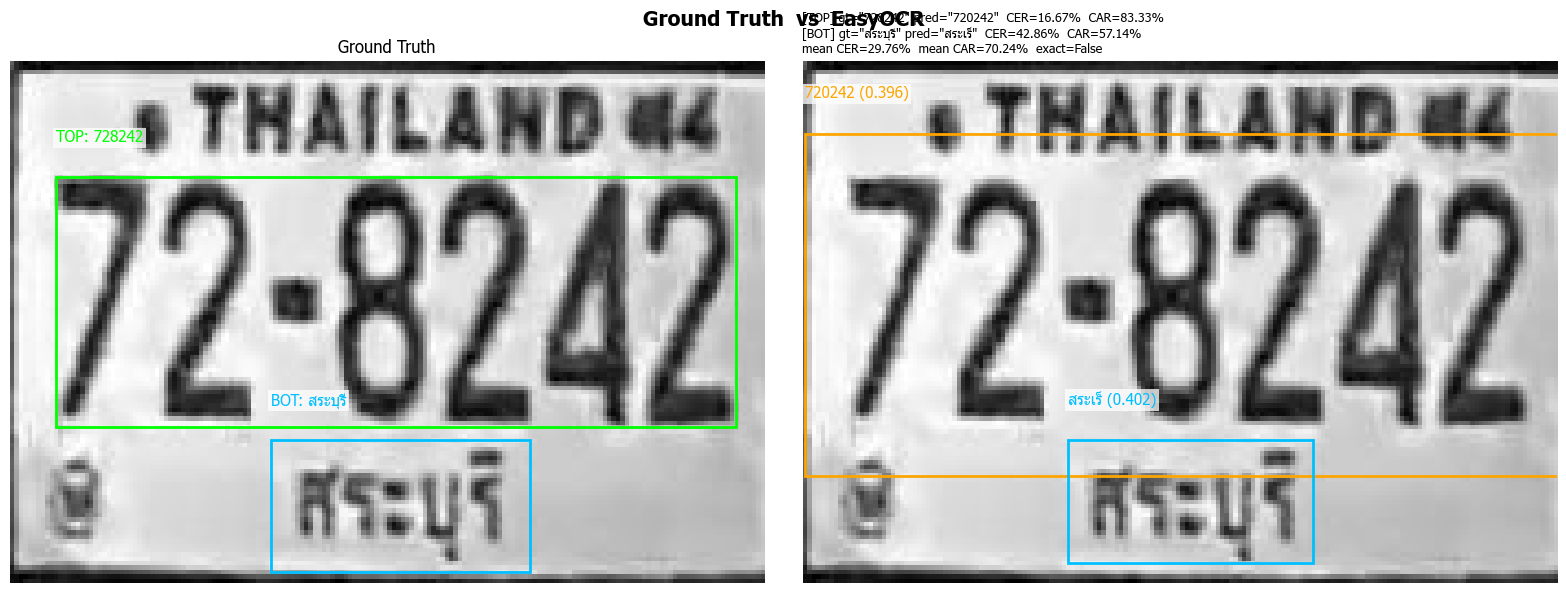

In [87]:
gt, ocr_result, metrics = evaluate_plate(
    csv_path=r'LPR-plate-1\test\_annotations.csv',
    image_dir=r'LPR-plate-1\test',
    province_map_path='province_map.csv',
    idx=200,
    gpu=True,
    reader=reader,
)

In [88]:
from tqdm import tqdm

def evaluate_all(csv_path, image_dir, province_map_path="province_map.csv",
                 gpu=False, conf_threshold=0.1, output_csv="ocr_eval_results.csv"):
    df_all = pd.read_csv(csv_path)
    filenames = df_all['filename'].unique()

    reader = easyocr.Reader(['th', 'en'], gpu=gpu)
    records = []

    for i, filename in tqdm(enumerate(filenames), total=len(filenames), desc="Evaluating OCR"):
        try:
            gt = build_ground_truth(csv_path, image_dir, province_map_path, idx=i)
            img_path = os.path.join(image_dir, gt["filename"])
            ocr_result = run_easyocr(img_path, gt,
                                     conf_threshold=conf_threshold,
                                     gpu=gpu, _reader=reader)
            metrics = evaluate(gt, ocr_result)

            records.append({
                "filename":         filename,
                # ── top line ──
                "top_gt":           metrics["top"]["gt_text"],
                "top_pred":         metrics["top"]["pred_text"],
                "top_cer":          metrics["top"]["cer"],
                "top_car":          metrics["top"]["car"],
                "top_exact":        metrics["top"]["exact_match"],
                "top_conf":         metrics["top"]["mean_conf"],
                # ── bottom line ──
                "bottom_gt":        metrics["bottom"]["gt_text"],
                "bottom_pred":      metrics["bottom"]["pred_text"],
                "bottom_cer":       metrics["bottom"]["cer"],
                "bottom_car":       metrics["bottom"]["car"],
                "bottom_exact":     metrics["bottom"]["exact_match"],
                "bottom_conf":      metrics["bottom"]["mean_conf"],
                # ── overall ──
                "mean_cer":         metrics["overall"]["mean_cer"],
                "mean_car":         metrics["overall"]["mean_car"],
                "exact_match_both": metrics["overall"]["exact_match_both"],
            })

        except Exception as e:
            records.append({"filename": filename, "error": str(e)})

    results_df = pd.DataFrame(records)
    results_df.to_csv(output_csv, index=False, encoding="utf-8-sig")

    ok = results_df.dropna(subset=["top_cer"])
    print(f"\n{'='*45}")
    print(f"  Total images    : {len(filenames)}")
    print(f"  Failed / skipped: {len(filenames) - len(ok)}")
    print(f"{'='*45}")
    print(f"  Top    CER : {ok['top_cer'].mean():.4f}")
    print(f"  Bottom CER : {ok['bottom_cer'].mean():.4f}")
    print(f"  Mean   CER : {ok['mean_cer'].mean():.4f}")
    print(f"{'─'*45}")
    print(f"  Top    CAR : {ok['top_car'].mean():.4f}")
    print(f"  Bottom CAR : {ok['bottom_car'].mean():.4f}")
    print(f"  Mean   CAR : {ok['mean_car'].mean():.4f}")
    print(f"{'='*45}")
    print(f"  Saved → {output_csv}")

    return results_df

In [89]:
results_df = evaluate_all(
    csv_path=r'LPR-plate-1\test\_annotations.csv',
    image_dir=r'LPR-plate-1\test',
    province_map_path='province_map.csv',
    output_csv='ocr_eval_results.csv',
    gpu=True,
)

Evaluating OCR: 100%|██████████| 200/200 [00:17<00:00, 11.30it/s]


  Total images    : 200
  Failed / skipped: 0
  Top    CER : 0.2746
  Bottom CER : 0.6332
  Mean   CER : 0.4539
─────────────────────────────────────────────
  Top    CAR : 0.7254
  Bottom CAR : 0.3668
  Mean   CAR : 0.5461
  Saved → ocr_eval_results.csv
